In [73]:
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
import torch.optim as optim

import matplotlib.pyplot as plt
import os
import random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
# torch.backends.cudnn.deterministic = True
# torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
print('torch:', torch.__version__)



device: cuda
torch: 2.10.0+cu128


In [74]:
def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    # Accuracy для классификации: logits -> argmax -> сравнение с y_true.
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()


def plot_history(history: dict, title: str = "") -> None:
    # history ожидается вида:
    # {
    #   "train_loss": [...], "val_loss": [...],
    #   "train_acc": [...],  "val_acc": [...]
    # }
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure()
    plt.plot(epochs, history["train_loss"], label="train_loss")
    plt.plot(epochs, history["val_loss"], label="val_loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title((title + " (loss)") if title else "loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure()
    plt.plot(epochs, history["train_acc"], label="train_acc")
    plt.plot(epochs, history["val_acc"], label="val_acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title((title + " (accuracy)") if title else "accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

In [75]:
transform = transforms.ToTensor()

train_full = torchvision.datasets.EMNIST(root="./data",split = 'balanced', train=True, download=True, transform=transform)
test_ds = torchvision.datasets.EMNIST(root="./data", split = 'balanced', train=False, download=True, transform=transform)

class_names = train_full.classes
print("classes:", class_names)
print("train size:", len(train_full))
print("test size:", len(test_ds))

BATCH_SIZE = 256
val_ratio = 0.2                                         #делим 80/20
val_size = int(len(train_full) * val_ratio)
train_size = len(train_full) - val_size

gen = torch.Generator().manual_seed(42)
train_ds, val_ds = random_split(train_full, [train_size, val_size], generator=gen)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True, pin_memory=(device.type == "cuda")
)

val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False, pin_memory=(device.type == "cuda")
)

test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False, pin_memory=(device.type == "cuda")
)

x_batch, y_batch = next(iter(train_loader))
x_batch, y_batch = x_batch.to(device), y_batch.to(device)
print("x_batch:", x_batch.shape, x_batch.dtype, x_batch.device)
print("y_batch:", y_batch.shape, y_batch.dtype, y_batch.device)

classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'd', 'e', 'f', 'g', 'h', 'n', 'q', 'r', 't']
train size: 112800
test size: 18800
x_batch: torch.Size([256, 1, 28, 28]) torch.float32 cuda:0
y_batch: torch.Size([256]) torch.int64 cuda:0


In [76]:
class MLP(nn.Module):
    def __init__(
        self,
        input_dim: int = 28 * 28,
        hidden_dims: tuple = (256, 128),
        num_classes: int = 47,
        activation: str = "relu",
        dropout_p: float = 0.0,
        use_batchnorm: bool = False,
    ):
        super().__init__()

        act_layer = nn.ReLU

        layers = [nn.Flatten()]

        prev = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(act_layer())
            if dropout_p > 0:
                layers.append(nn.Dropout(p=dropout_p))
            prev = h

        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [89]:
# Earlystopping

class EarlyStopping:
    def __init__(self, patience: int = 5, min_delta: float = 0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.best_state = None
        self.counter = 0

    def step(self, score: float, model: nn.Module) -> bool:
        # score: чем больше, тем лучше (например, val_acc).
        # Возвращает True, если нужно остановиться.
        if self.best_score is None:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            return False

        if score > self.best_score + self.min_delta:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
            return False

        self.counter += 1
        return self.counter >= self.patience

    def restore_best(self, model: nn.Module) -> None:
        if self.best_state is not None:
            model.load_state_dict(self.best_state)

In [78]:
#Функции эпох и вычислений

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train() 
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval() 
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches

In [79]:
#Функция логирования

def fit(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    epochs: int = 20,
    early_stopping=None,
    verbose: bool = True,
):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        va_loss, va_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        if verbose:
            print(
                f"epoch {epoch:02d}/{epochs} | "
                f"train loss={tr_loss:.4f}, acc={tr_acc:.4f} | "
                f"val loss={va_loss:.4f}, acc={va_acc:.4f}"
            )

        if early_stopping is not None:
            should_stop = early_stopping.step(va_acc, model)
            if should_stop:
                if verbose:
                    print(
                        f"EarlyStopping: остановка на эпохе {epoch}. "
                        f"Лучший val_acc={early_stopping.best_score:.4f}"
                    )
                early_stopping.restore_best(model)
                break

    return history

In [ ]:
#   Обучение моделей 1-3 для экспериментов

default_model = MLP(hidden_dims=(256, 128, 64), dropout_p=0.0, use_batchnorm=False).to(device) # модель 1
dropout_model = MLP(hidden_dims=(256, 128, 64), dropout_p=0.3, use_batchnorm=False).to(device) # модель 2
batchnorm_model = MLP(hidden_dims=(256, 128, 64), dropout_p=0.0, use_batchnorm=True).to(device) # модель 3

epoch 01/20 | train loss=1.6495, acc=0.5385 | val loss=0.9905, acc=0.7103
epoch 02/20 | train loss=0.8561, acc=0.7390 | val loss=0.7810, acc=0.7626
epoch 03/20 | train loss=0.6902, acc=0.7842 | val loss=0.6672, acc=0.7937
epoch 04/20 | train loss=0.6022, acc=0.8061 | val loss=0.6215, acc=0.8043
epoch 05/20 | train loss=0.5432, acc=0.8218 | val loss=0.5759, acc=0.8118
epoch 06/20 | train loss=0.5003, acc=0.8345 | val loss=0.5675, acc=0.8196
epoch 07/20 | train loss=0.4685, acc=0.8426 | val loss=0.5429, acc=0.8290
epoch 08/20 | train loss=0.4412, acc=0.8486 | val loss=0.5292, acc=0.8295
epoch 09/20 | train loss=0.4191, acc=0.8547 | val loss=0.5154, acc=0.8344
epoch 10/20 | train loss=0.3962, acc=0.8618 | val loss=0.5101, acc=0.8344
epoch 11/20 | train loss=0.3789, acc=0.8665 | val loss=0.4957, acc=0.8377
epoch 12/20 | train loss=0.3614, acc=0.8712 | val loss=0.5081, acc=0.8360
epoch 13/20 | train loss=0.3472, acc=0.8753 | val loss=0.5133, acc=0.8364
epoch 14/20 | train loss=0.3350, acc=0

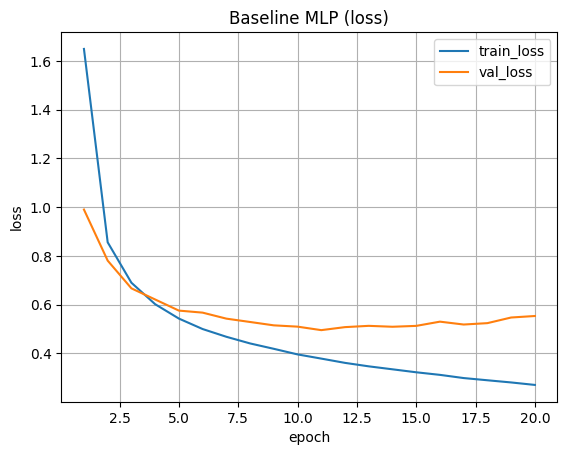

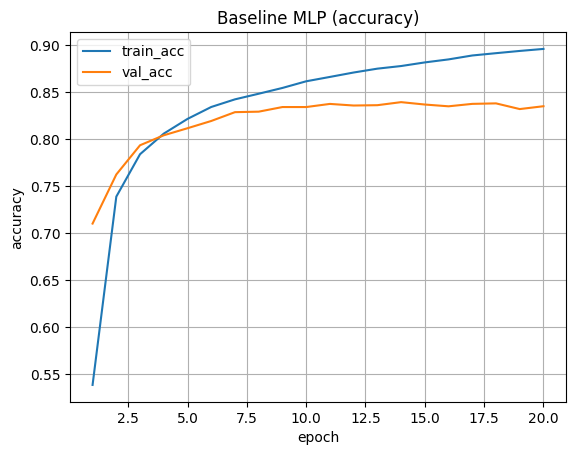

Default test: loss=0.5835, acc=0.8340


In [81]:
#   Модель 1
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(default_model.parameters(), lr=1e-3)

history_default = fit(
    default_model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

plot_history(history_default, title="Baseline MLP")
test_loss, test_acc = evaluate(default_model, test_loader, criterion, device)
print(f"Default test: loss={test_loss:.4f}, acc={test_acc:.4f}")


epoch 01/20 | train loss=2.1260, acc=0.3958 | val loss=1.0592, acc=0.6875
epoch 02/20 | train loss=1.2336, acc=0.6270 | val loss=0.8090, acc=0.7474
epoch 03/20 | train loss=1.0442, acc=0.6796 | val loss=0.7071, acc=0.7756
epoch 04/20 | train loss=0.9468, acc=0.7070 | val loss=0.6633, acc=0.7862
epoch 05/20 | train loss=0.8837, acc=0.7227 | val loss=0.6215, acc=0.8021
epoch 06/20 | train loss=0.8376, acc=0.7376 | val loss=0.5913, acc=0.8085
epoch 07/20 | train loss=0.8023, acc=0.7464 | val loss=0.5775, acc=0.8140
epoch 08/20 | train loss=0.7748, acc=0.7546 | val loss=0.5618, acc=0.8165
epoch 09/20 | train loss=0.7443, acc=0.7624 | val loss=0.5463, acc=0.8215
epoch 10/20 | train loss=0.7318, acc=0.7656 | val loss=0.5387, acc=0.8216
epoch 11/20 | train loss=0.7122, acc=0.7710 | val loss=0.5282, acc=0.8236
epoch 12/20 | train loss=0.6985, acc=0.7752 | val loss=0.5240, acc=0.8277
epoch 13/20 | train loss=0.6863, acc=0.7783 | val loss=0.5148, acc=0.8272
epoch 14/20 | train loss=0.6727, acc=0

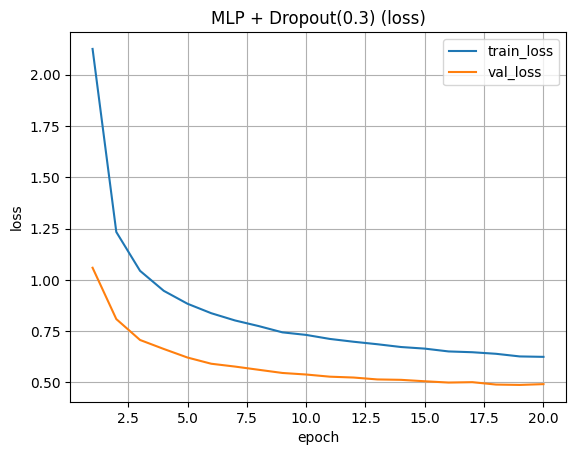

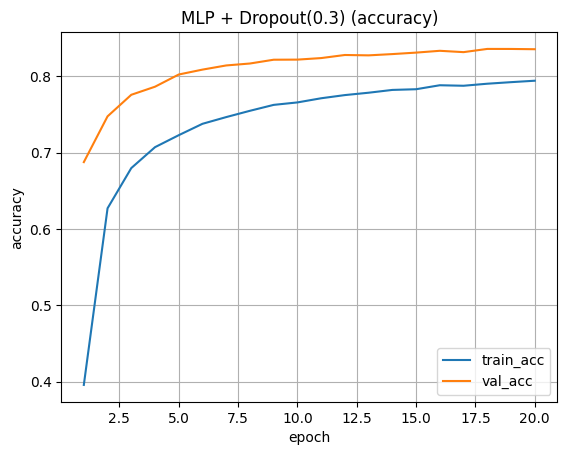

Dropout test: loss=0.5036, acc=0.8329


In [82]:
#   Модель 2
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(dropout_model.parameters(), lr=1e-3)

history_dropout = fit(
    dropout_model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

plot_history(history_dropout, title="MLP + Dropout(0.3)")
test_loss, test_acc = evaluate(dropout_model, test_loader, criterion, device)
print(f"Dropout test: loss={test_loss:.4f}, acc={test_acc:.4f}")


epoch 01/20 | train loss=1.3195, acc=0.6957 | val loss=0.6911, acc=0.7896
epoch 02/20 | train loss=0.5635, acc=0.8217 | val loss=0.5355, acc=0.8278
epoch 03/20 | train loss=0.4581, acc=0.8455 | val loss=0.4936, acc=0.8362
epoch 04/20 | train loss=0.4016, acc=0.8609 | val loss=0.4764, acc=0.8401
epoch 05/20 | train loss=0.3673, acc=0.8698 | val loss=0.4655, acc=0.8451
epoch 06/20 | train loss=0.3355, acc=0.8776 | val loss=0.4649, acc=0.8411
epoch 07/20 | train loss=0.3141, acc=0.8844 | val loss=0.4753, acc=0.8431
epoch 08/20 | train loss=0.2942, acc=0.8905 | val loss=0.4650, acc=0.8477
epoch 09/20 | train loss=0.2766, acc=0.8946 | val loss=0.4667, acc=0.8471
epoch 10/20 | train loss=0.2636, acc=0.8995 | val loss=0.4750, acc=0.8471
epoch 11/20 | train loss=0.2505, acc=0.9040 | val loss=0.4837, acc=0.8448
epoch 12/20 | train loss=0.2385, acc=0.9066 | val loss=0.4879, acc=0.8458
epoch 13/20 | train loss=0.2277, acc=0.9103 | val loss=0.4990, acc=0.8449
epoch 14/20 | train loss=0.2184, acc=0

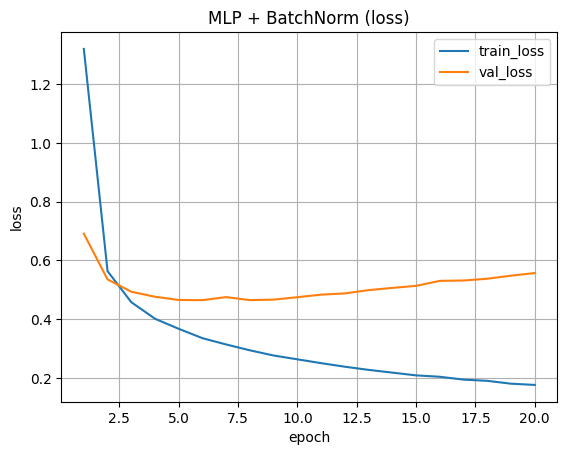

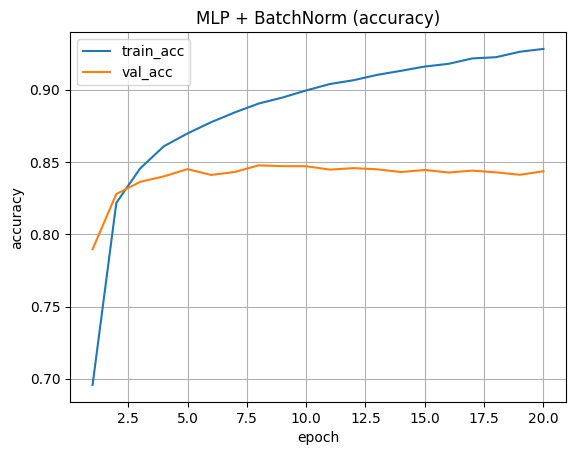

BatchNorm test: loss=0.5815, acc=0.8404


In [83]:
#   Модель 3
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(batchnorm_model.parameters(), lr=1e-3)

history_bn = fit(
    batchnorm_model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

plot_history(history_bn, title="MLP + BatchNorm")
test_loss, test_acc = evaluate(batchnorm_model, test_loader, criterion, device)
print(f"BatchNorm test: loss={test_loss:.4f}, acc={test_acc:.4f}")


In [88]:
val_acc_dp_model = history_default['val_acc']
val_acc_bn_model = history_bn['val_acc']

best_val_acc_dp = max(val_acc_dp_model)
best_val_acc_bn = max(val_acc_bn_model)

if best_val_acc_dp > best_val_acc_bn:
    winner_val_acc = best_val_acc_dp
    print("Dropout Модель показала лучшие результаты")  
else:
    winner_val_acc = best_val_acc_bn
    print("BatchNorm Модель показала лучшие результаты")
print("Лучшая точность валидации:", winner_val_acc)

BatchNorm Модель показала лучшие результаты
Лучшая точность валидации: 0.8477001404494382


In [ ]:
final_model = MLP(hidden_dims=(256, 128, 64), dropout_p=0.0, use_batchnorm=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(final_model.parameters(), lr=1e-3)

es = EarlyStopping(patience=4, min_delta=0.0005)

history_final = fit(
    final_model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=50, 
    early_stopping=es,
    verbose=True
)

plot_history(history_final, title="MLP + Dropout + BatchNorm + EarlyStopping")
test_loss, test_acc = evaluate(final_model, test_loader, criterion, device)
print(f"Combo test: loss={test_loss:.4f}, acc={test_acc:.4f}")

epoch 01/50 | train loss=2.0092, acc=0.4908 | val loss=0.9320, acc=0.7318
epoch 02/50 | train loss=1.1392, acc=0.6572 | val loss=0.7113, acc=0.7747


KeyboardInterrupt: 